In [ ]:
!pip install xgboost
!pip install scikit-image
!pip install joblib

In [ ]:
import numpy as np
import pandas as pd
import cv2
import os
import joblib

from skimage.feature import graycomatrix
from skimage.feature import graycoprops

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image

import matplotlib.pyplot as plt

In [ ]:
import os

print(os.listdir())

['.config', 'CP-AnemiC dataset (1).rar', 'sample_data']


In [ ]:
!apt-get install unrar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [ ]:
!unrar x "CP-AnemiC dataset (1).rar"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from CP-AnemiC dataset (1).rar

Creating    Anemic                                                    OK
Extracting  Anemic/Image_001.png                                           0%  OK 
Extracting  Anemic/Image_002.png                                           0%  OK 
Extracting  Anemic/Image_005.png                                           0%  OK 
Extracting  Anemic/Image_007.png                                           1%  OK 
Extracting  Anemic/Image_009.png                                           1%  OK 
Extracting  Anemic/Image_010.png                                           1%  OK 
Extracting  Anemic/Image_013.png                                           1%  OK 
Extracting  Anemic/Image_015.png                                           1%  OK 
Extracting  Anemic/Image_016.png                                        

In [ ]:
df=pd.read_excel("Anemia_Data_Collection_Sheet.xlsx")

print(df.head())

print("Total:",len(df))

    IMAGE_ID  HB_LEVEL    Severity  Age(Months)  GENDER      REMARK  \
0  Image_001       9.8    Moderate            6  Female      Anemic   
1  Image_002       9.9    Moderate           24    Male      Anemic   
2  Image_003      11.1  Non-Anemic           24  Female  Non-anemic   
3  Image_004      12.5  Non-Anemic           12    Male  Non-anemic   
4  Image_005       9.9    Moderate           24    Male      Anemic   

                           HOSPITAL     CITY/TOWN   MUNICIPALITY/DISTRICT  \
0  Nkawie-Toase Government Hospital  Nkawie-Toase  Atwima Nwabiagya South   
1         Ejusu Government Hospital         Ejusu      Ejusu Municipality   
2         Ahmadiyya Muslim Hospital      Tachiman   Techiman Municipality   
3         Ahmadiyya Muslim Hospital      Tachiman   Techiman Municipality   
4        Sunyani Municipal Hospital       Sunyani    Sunyani Municipality   

      REGION COUNTRY  
0    Ashanti   Ghana  
1    Ashanti   Ghana  
2  Bono-East   Ghana  
3  Bono-East   Gha

In [ ]:
image_paths=[]

for _,row in df.iterrows():

    img=str(row["IMAGE_ID"])+".png"

    path1="Anemic/"+img

    path2="Non-anemic/"+img

    if os.path.exists(path1):

        image_paths.append(path1)

    elif os.path.exists(path2):

        image_paths.append(path2)

    else:

        print("Missing:",img)

        image_paths.append(None)

df["image_path"]=image_paths

df=df[df["image_path"].notna()]

In [ ]:
for path in df["image_path"][:10]:

    img=cv2.imread(path)

    if img is None:

        print("FAIL:",path)

    else:

        print("OK:",path)

OK: Anemic/Image_001.png
OK: Anemic/Image_002.png
OK: Non-anemic/Image_003.png
OK: Non-anemic/Image_004.png
OK: Anemic/Image_005.png
OK: Non-anemic/Image_006.png
OK: Anemic/Image_007.png
OK: Non-anemic/Image_008.png
OK: Anemic/Image_009.png
OK: Anemic/Image_010.png


In [ ]:
def extract_conjunctiva(image):
    import cv2
    import numpy as np

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    L, A, B = cv2.split(lab)
    H, S, V = cv2.split(hsv)

    # 🔥 STEP 1: Adaptive threshold (instead of fixed 145)
    A_blur = cv2.GaussianBlur(A, (5,5), 0)
    _, mask_A = cv2.threshold(
        A_blur,
        np.mean(A_blur) + 5,   # adaptive threshold
        255,
        cv2.THRESH_BINARY
    )

    # 🔥 STEP 2: Brightness filter (conjunctiva is usually brighter)
    _, mask_L = cv2.threshold(L, np.mean(L), 255, cv2.THRESH_BINARY)

    # 🔥 STEP 3: Low saturation (pale/yellow eyes handled)
    _, mask_S = cv2.threshold(S, 80, 255, cv2.THRESH_BINARY_INV)

    # 🔥 Combine all masks
    mask = cv2.bitwise_and(mask_A, mask_L)
    mask = cv2.bitwise_and(mask, mask_S)

    # 🔥 Morphology cleanup
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # 🔥 Find contours
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    # 🔥 Choose best contour (not just largest)
    best = None
    best_score = 0

    for cnt in contours:
        area = cv2.contourArea(cnt)

        x, y, w, h = cv2.boundingRect(cnt)

        # ignore tiny or weird shapes
        if area < 500:
            continue

        aspect_ratio = w / (h + 1e-5)

        # conjunctiva is horizontally stretched
        score = area * aspect_ratio

        if score > best_score:
            best_score = score
            best = cnt

    if best is None:
        return None

    # 🔥 Extract ROI
    x, y, w, h = cv2.boundingRect(best)

    clean = np.zeros_like(mask)
    cv2.drawContours(clean, [best], -1, 255, -1)

    roi = cv2.bitwise_and(rgb, rgb, mask=clean)
    roi = roi[y:y+h, x:x+w]

    roi = cv2.resize(roi, (224, 224))

    return roi

In [ ]:
def normalize_image(img):
    import cv2
    import numpy as np

    # 1. Resize (consistent input)
    img = cv2.resize(img, (600, 400))

    # 2. Convert to float
    img = img.astype(np.float32)

    # 3. Gray World Assumption (color constancy)
    # balances color across cameras
    avg_b = np.mean(img[:, :, 0])
    avg_g = np.mean(img[:, :, 1])
    avg_r = np.mean(img[:, :, 2])

    avg_gray = (avg_b + avg_g + avg_r) / 3

    img[:, :, 0] *= (avg_gray / (avg_b + 1e-6))
    img[:, :, 1] *= (avg_gray / (avg_g + 1e-6))
    img[:, :, 2] *= (avg_gray / (avg_r + 1e-6))

    # clip values
    img = np.clip(img, 0, 255)

    # 4. Convert to LAB for gentle brightness normalization
    img = img.astype(np.uint8)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    # 🔥 mild normalization (no CLAHE)
    l = cv2.normalize(l, None, 0, 255, cv2.NORM_MINMAX)

    lab = cv2.merge((l, a, b))

    # 5. Back to BGR
    normalized = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    return normalized

In [ ]:
cnn_model=ResNet50(

    weights="imagenet",

    include_top=False,

    pooling="avg"
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def extract_cnn_features(path):

    img=cv2.imread(path)

    img=normalize_image(img)

    roi=extract_conjunctiva(img)

    if roi is None:

        roi=img

    roi=cv2.resize(roi,(224,224))

    roi=cv2.cvtColor(
        roi,
        cv2.COLOR_BGR2RGB
    )

    roi=image.img_to_array(roi)

    roi=np.expand_dims(roi,axis=0)

    roi=preprocess_input(roi)

    features=cnn_model.predict(
        roi,
        verbose=0
    )

    return features.flatten()

In [ ]:
def extract_features(path):

    img=cv2.imread(path)

    if img is None:
        return np.zeros(18)

    img=normalize_image(img)

    roi=extract_conjunctiva(img)

    if roi is None:
        roi=img

    img=cv2.resize(roi,(224,224))

    rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    R=rgb[:,:,0].astype(np.float32)
    G=rgb[:,:,1].astype(np.float32)
    B=rgb[:,:,2].astype(np.float32)


    # ======================
    # ORIGINAL 18 FEATURES
    # ======================

    mean_r=np.mean(R)
    mean_g=np.mean(G)
    mean_b=np.mean(B)

    std_r=np.std(R)
    std_g=np.std(G)
    std_b=np.std(B)

    rg_diff=np.mean(R-G)

    r_ratio=np.mean(R/(R+G+B+1e-5))


    lab=cv2.cvtColor(img,cv2.COLOR_BGR2LAB)

    L=lab[:,:,0].astype(np.float32)
    A=lab[:,:,1].astype(np.float32)
    B2=lab[:,:,2].astype(np.float32)

    mean_l=np.mean(L)
    mean_a=np.mean(A)
    mean_b2=np.mean(B2)

    std_l=np.std(L)
    std_a=np.std(A)
    std_b2=np.std(B2)

    a_l_ratio=np.mean(A/(L+1e-5))


    gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    glcm=graycomatrix(
        gray,
        [1],
        [0],
        256,
        symmetric=True,
        normed=True
    )

    contrast=graycoprops(glcm,'contrast')[0,0]

    homogeneity=graycoprops(glcm,'homogeneity')[0,0]

    energy=graycoprops(glcm,'energy')[0,0]


    # ======================
    # FINAL RETURN
    # ======================

    original_features=[

        mean_r,mean_g,mean_b,

        std_r,std_g,std_b,

        rg_diff,r_ratio,

        mean_l,mean_a,mean_b2,

        std_l,std_a,std_b2,

        a_l_ratio,

        contrast,

        homogeneity,

        energy
    ]


    return np.array(original_features)

Handcrafted: (710, 18)
CNN: (710, 2048)


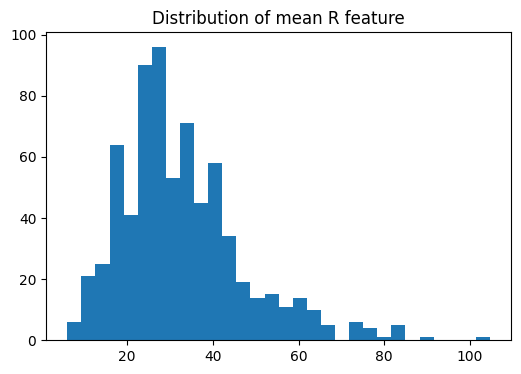

In [ ]:
features=[]
cnn_features=[]

for path in df["image_path"]:

    features.append(
        extract_features(path)
    )

    cnn_features.append(
        extract_cnn_features(path)
    )

X=np.array(features)

cnn_features=np.array(cnn_features)

print("Handcrafted:",X.shape)
print("CNN:",cnn_features.shape)

plt.figure(figsize=(6,4))

plt.hist(X[:,0],bins=30)

plt.title("Distribution of mean R feature")

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

cnn_scaler = StandardScaler()

cnn_scaled = cnn_scaler.fit_transform(cnn_features)

print("CNN scaled shape:", cnn_scaled.shape)

CNN scaled shape: (710, 2048)


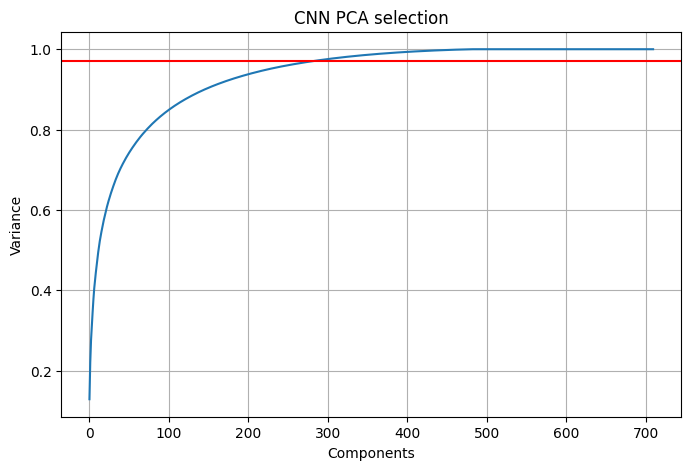

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()

pca.fit(cnn_scaled)

variance = pca.explained_variance_ratio_

cumulative = np.cumsum(variance)

plt.figure(figsize=(8,5))

plt.plot(cumulative)

plt.axhline(0.97,color='r')

plt.xlabel("Components")

plt.ylabel("Variance")

plt.title("CNN PCA selection")

plt.grid()

plt.show()

In [ ]:
pca = PCA(n_components=300)

cnn_pca = pca.fit_transform(cnn_scaled)

print("CNN PCA shape:",cnn_pca.shape)

CNN PCA shape: (710, 300)


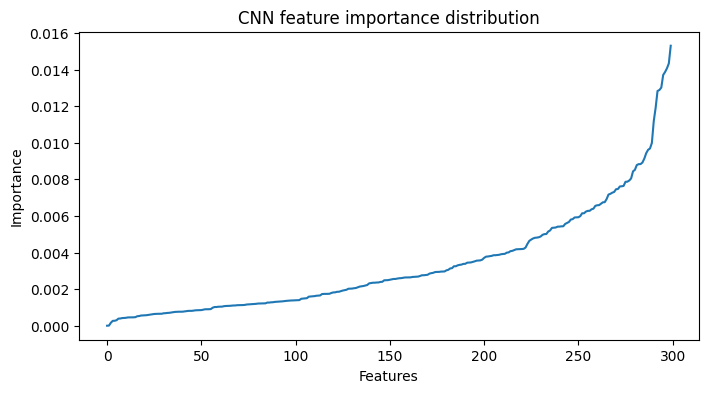

Max importance: 0.015304024
Min importance: 0.0


In [ ]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import numpy as np

y = df["HB_LEVEL"].values

temp_model = XGBRegressor(

    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    random_state=42

)

temp_model.fit(cnn_pca,y)

importance = temp_model.feature_importances_

plt.figure(figsize=(8,4))

plt.plot(np.sort(importance))

plt.title("CNN feature importance distribution")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

print("Max importance:",np.max(importance))

print("Min importance:",np.min(importance))

In [ ]:
age = df["Age(Months)"].values

gender = df["GENDER"].apply(
    lambda x: 1 if str(x).lower()=="male"
    else 0
).values

severity = df["Severity"].apply(

    lambda x: 0 if "non" in str(x).lower()
    else 1

).values

print("Age shape:",age.shape)
print("Gender shape:",gender.shape)
print("Severity shape:",severity.shape)

Age shape: (710,)
Gender shape: (710,)
Severity shape: (710,)


In [ ]:
print(df.columns)

Index(['IMAGE_ID', 'HB_LEVEL', 'Severity', 'Age(Months)', 'GENDER', 'REMARK',
       'HOSPITAL', 'CITY/TOWN', 'MUNICIPALITY/DISTRICT', 'REGION', 'COUNTRY',
       'image_path'],
      dtype='object')


In [ ]:
hb=df["HB_LEVEL"].values

severity3=[]

for v in hb:

    if v>11:
        severity3.append(0)

    elif v>8.5:
        severity3.append(1)

    else:
        severity3.append(2)

severity3=np.array(severity3)

print(np.bincount(severity3))

[277 288 145]


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

# ===== FIXED 70 FEATURES, NO SEVERITY LEAKAGE =====
n       = 70
cnn_idx = np.argsort(importance)[-n:]

cnn_selected = cnn_pca[:, cnn_idx]

X_all = np.column_stack([
    X,
    cnn_selected,
    np.array(age).reshape(-1,1),
    np.array(gender).reshape(-1,1)
])

scaler = StandardScaler()
X_all  = scaler.fit_transform(X_all)

hb_bins = pd.qcut(y, 5, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y,
    test_size=0.2,
    stratify=hb_bins,
    random_state=42
)

model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.6,
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)
mae  = mean_absolute_error(y_test, pred)

print("MAE:", mae)
print("X_all shape        :", X_all.shape)
print("Scaler now expects :", scaler.n_features_in_, "features")

MAE: 1.6078344102644584
X_all shape        : (710, 90)
Scaler now expects : 90 features


In [ ]:
hb = df["HB_LEVEL"].values

severity3 = []
for v in hb:
    if v > 11:
        severity3.append(0)
    elif v > 8.5:
        severity3.append(1)
    else:
        severity3.append(2)

severity3 = np.array(severity3)
print(np.bincount(severity3))

pred_all = []
true_all = []

for g in [0, 1, 2]:
    group_idx = np.where(severity3 == g)[0]   # FIXED name
    Xg = X_all[group_idx]
    yg = y[group_idx]

    X_train, X_test, y_train, y_test = train_test_split(
        Xg, yg, test_size=0.2, random_state=42
    )

    m = XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.7,
        colsample_bytree=0.6,
        random_state=42
    )
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    pred_all.extend(pred)
    true_all.extend(y_test)

mae = mean_absolute_error(true_all, pred_all)
print("Grouped regression MAE:", mae)

[277 288 145]
Grouped regression MAE: 0.7272097098077093


In [ ]:
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBRegressor

# ===== CREATE SEVERITY LABELS =====
hb = df["HB_LEVEL"].values

severity3 = []
for v in hb:
    if v > 11:
        severity3.append(0)   # Normal
    elif v > 8.5:
        severity3.append(1)   # Mild
    else:
        severity3.append(2)   # Severe

severity3 = np.array(severity3)
print("Class distribution:", np.bincount(severity3))


# ============================================================
# 🔥 STEP 1: AUTOMATIC CLASS WEIGHT (ROBUST)
# ============================================================

classes = np.unique(severity3)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=severity3
)

class_weights = dict(zip(classes, weights))
print("Auto class weights:", class_weights)

# Convert to sample-wise weights
sample_weights = np.array([class_weights[label] for label in severity3])


# ============================================================
# 🔥 STEP 2: TRAIN SEVERITY CLASSIFIER (CORRECT WAY)
# ============================================================

# Train base model WITH weights
base_clf = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

base_clf.fit(X_all, severity3, sample_weight=sample_weights)

# Calibrate AFTER training (no weights here)
severity_clf = CalibratedClassifierCV(base_clf, cv=5, method='isotonic')
severity_clf.fit(X_all, severity3)

print("Severity classifier trained with automatic weighting.")


# ============================================================
# 🔥 STEP 3: TRAIN EXPERT MODELS (UNCHANGED)
# ============================================================

expert_models = {}
pred_all = []
true_all = []

for g in [0, 1, 2]:
    group_idx = np.where(severity3 == g)[0]
    Xg = X_all[group_idx]
    yg = y[group_idx]

    X_train, X_test, y_train, y_test = train_test_split(
        Xg, yg, test_size=0.2, random_state=42
    )

    model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.7,
        colsample_bytree=0.6,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    pred_all.extend(pred)
    true_all.extend(y_test)

    expert_models[g] = model

# Evaluate regression
mae = mean_absolute_error(true_all, pred_all)
print("Grouped regression MAE:", mae)


# ============================================================
# 🔥 STEP 4: SAVE EVERYTHING
# ============================================================

joblib.dump(expert_models, "hb_models.pkl")
joblib.dump(scaler,        "scaler.pkl")
joblib.dump(pca,           "pca.pkl")
joblib.dump(cnn_scaler,    "cnn_scaler.pkl")
joblib.dump(cnn_idx,       "cnn_idx.pkl")
joblib.dump(severity_clf,  "severity_clf.pkl")

print("All models saved successfully.")
print("cnn_idx length saved:", len(cnn_idx))  # should be 70

Class distribution: [277 288 145]
Auto class weights: {np.int64(0): np.float64(0.8543922984356197), np.int64(1): np.float64(0.8217592592592593), np.int64(2): np.float64(1.632183908045977)}
Severity classifier trained with automatic weighting.
Grouped regression MAE: 0.7272097098077093
All models saved successfully.
cnn_idx length saved: 70


cnn_idx length: 70
Scaler expects: 90


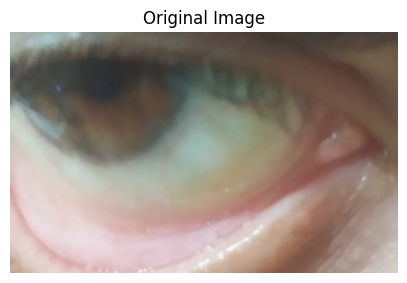

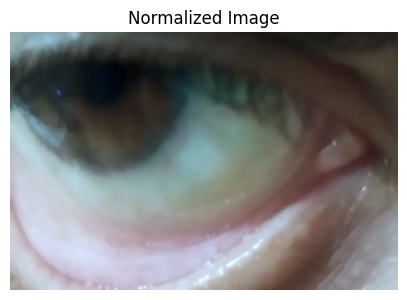

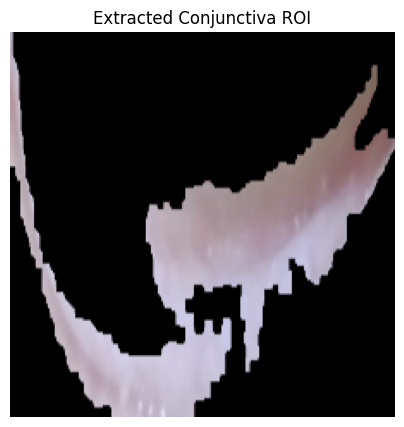

Final feature size: (1, 90)

====== SEVERITY PROBABILITIES ======
  P(Normal) : 0.032  (3.2%)
  P(Mild)   : 0.616  (61.6%)
  P(Severe) : 0.352  (35.2%)

====== EXPERT Hb PREDICTIONS ======
  Expert Normal : 12.60 g/dL
  Expert Mild   : 10.20 g/dL
  Expert Severe : 6.47 g/dL

====== ADJACENT PAIR SELECTED ======
  Using  : Mild (P=0.616) + Severe (P=0.352)
  Dropped: Normal (P=0.032)

====== FINAL RESULT ======
  Predicted Hb     : 8.84 g/dL
  Uncertainty (±1σ): ±1.79 g/dL
  95% CI           : [5.33, 12.36] g/dL
  Condition        : Mild Anemia
  Most likely class: Mild Anemia  (confidence: 61.6%)


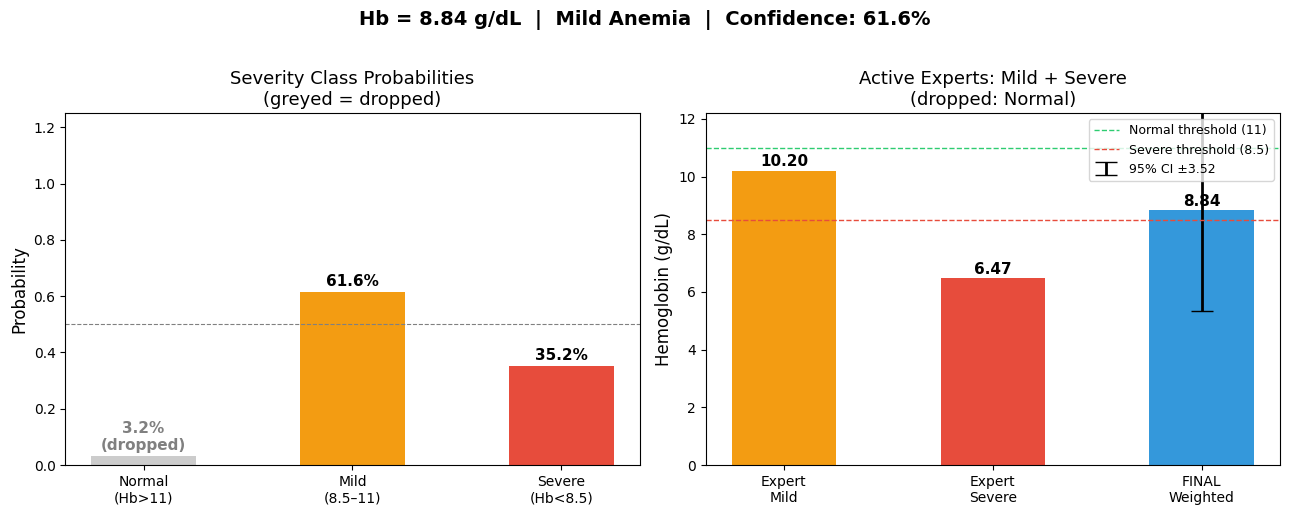

In [ ]:
import joblib
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ===== LOAD =====
models       = joblib.load("hb_models.pkl")
scaler       = joblib.load("scaler.pkl")
pca          = joblib.load("pca.pkl")
cnn_scaler   = joblib.load("cnn_scaler.pkl")
cnn_idx      = joblib.load("cnn_idx.pkl")
severity_clf = joblib.load("severity_clf.pkl")

print("cnn_idx length:", len(cnn_idx))         # must be 70
print("Scaler expects:", scaler.n_features_in_) # must be 90 (18+70+age+gender)

# ===== LOAD IMAGE =====
path = "eye17.jpeg"
img  = cv2.imread(path)

plt.figure(figsize=(5,5))
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

norm = normalize_image(img)

plt.figure(figsize=(5,5))
plt.title("Normalized Image")
plt.imshow(cv2.cvtColor(norm, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

roi = extract_conjunctiva(norm)8
if roi is None:
    roi = norm

plt.figure(figsize=(5,5))
plt.title("Extracted Conjunctiva ROI")
plt.imshow(roi)
plt.axis('off')
plt.show()

# ===== FEATURE EXTRACTION =====
hand         = extract_features(path)
hand         = np.array(hand)                  # shape (18,) — NO manual normalization

cnn          = extract_cnn_features(path)
cnn          = cnn.reshape(1, -1)
cnn_scaled_f = cnn_scaler.transform(cnn)
cnn_pca_f    = pca.transform(cnn_scaled_f)
cnn_selected = cnn_pca_f[:, cnn_idx]           # shape (1, 70)

# ===== METADATA =====
age_val    = 50
gender_val = 1

# ===== BUILD FEATURE VECTOR — matches training exactly =====
X_base = np.column_stack([
    hand.reshape(1, -1),                        # (1, 18)
    cnn_selected,                               # (1, 70)
    [[age_val, gender_val]]                     # (1, 2)
])                                              # total: (1, 90)

X_base = scaler.transform(X_base)
print("Final feature size:", X_base.shape)     # must be (1, 90)

# ===== STEP 1: CLASS PROBABILITIES =====
proba    = severity_clf.predict_proba(X_base)[0]
P_normal = proba[0]
P_mild   = proba[1]
P_severe = proba[2]

print("\n====== SEVERITY PROBABILITIES ======")
print(f"  P(Normal) : {P_normal:.3f}  ({P_normal*100:.1f}%)")
print(f"  P(Mild)   : {P_mild:.3f}  ({P_mild*100:.1f}%)")
print(f"  P(Severe) : {P_severe:.3f}  ({P_severe*100:.1f}%)")

# ===== STEP 2: EXPERT Hb PREDICTIONS =====
hb_preds = {}
for g in [0, 1, 2]:
    hb_preds[g] = models[g].predict(X_base)[0]

print("\n====== EXPERT Hb PREDICTIONS ======")
print(f"  Expert Normal : {hb_preds[0]:.2f} g/dL")
print(f"  Expert Mild   : {hb_preds[1]:.2f} g/dL")
print(f"  Expert Severe : {hb_preds[2]:.2f} g/dL")

# ===== STEP 3: ADJACENT TOP-2 WEIGHTED COMBINATION =====
# Severity order is 0=Normal, 1=Mild, 2=Severe (strictly ordered)
# Only adjacent pairs are valid: (Normal+Mild) or (Mild+Severe)
# Normal+Severe is never allowed — they are not neighbors on the scale

severity_probs = np.array([P_normal, P_mild, P_severe])
names          = ["Normal", "Mild", "Severe"]

# Anchor on the most probable class
top1 = int(np.argmax(severity_probs))

# Among its immediate neighbors, pick the one with higher probability
neighbors = [i for i in [top1 - 1, top1 + 1] if 0 <= i <= 2]
top2      = max(neighbors, key=lambda i: severity_probs[i])

# Final adjacent pair, sorted for consistent indexing
pair = sorted([top1, top2])

print(f"\n====== ADJACENT PAIR SELECTED ======")
print(f"  Using  : {names[pair[0]]} (P={severity_probs[pair[0]]:.3f}) + "
      f"{names[pair[1]]} (P={severity_probs[pair[1]]:.3f})")
dropped = [i for i in range(3) if i not in pair][0]
print(f"  Dropped: {names[dropped]} (P={severity_probs[dropped]:.3f})")

# Re-normalize the two selected weights to sum to 1
pair_probs       = severity_probs[pair]
pair_probs_norm  = pair_probs / pair_probs.sum()

# Weighted Hb blend
hb_final = (pair_probs_norm[0] * hb_preds[pair[0]] +
            pair_probs_norm[1] * hb_preds[pair[1]])

# ===== STEP 4: UNCERTAINTY =====
hb_variance = (pair_probs_norm[0] * (hb_preds[pair[0]] - hb_final)**2 +
               pair_probs_norm[1] * (hb_preds[pair[1]] - hb_final)**2)
hb_std  = np.sqrt(hb_variance)
ci_low  = hb_final - 1.96 * hb_std
ci_high = hb_final + 1.96 * hb_std

print("\n====== FINAL RESULT ======")
print(f"  Predicted Hb     : {hb_final:.2f} g/dL")
print(f"  Uncertainty (±1σ): ±{hb_std:.2f} g/dL")
print(f"  95% CI           : [{ci_low:.2f}, {ci_high:.2f}] g/dL")

if hb_final > 11:
    condition = "Normal"
elif hb_final > 8.5:
    condition = "Mild Anemia"
else:
    condition = "Severe Anemia"

dominant_idx  = int(np.argmax(proba))
dominant_name = ["Normal", "Mild Anemia", "Severe Anemia"][dominant_idx]
dominant_conf = proba[dominant_idx]

print(f"  Condition        : {condition}")
print(f"  Most likely class: {dominant_name}  (confidence: {dominant_conf*100:.1f}%)")

# ===== VISUALIZATION =====
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Severity probabilities with active/dropped styling ---
ax1        = axes[0]
bar_labels = ["Normal\n(Hb>11)", "Mild\n(8.5–11)", "Severe\n(Hb<8.5)"]
bar_colors_prob = []
for i, c in enumerate(["#2ecc71", "#f39c12", "#e74c3c"]):
    bar_colors_prob.append(c if i in pair else "#cccccc")  # grey out dropped

bars = ax1.bar(bar_labels, [P_normal, P_mild, P_severe],
               color=bar_colors_prob, width=0.5)

for bar, p, i in zip(bars, [P_normal, P_mild, P_severe], range(3)):
    label = f"{p*100:.1f}%"
    if i == dropped:
        label += "\n(dropped)"
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             label,
             ha='center', va='bottom', fontsize=11, fontweight='bold',
             color='gray' if i == dropped else 'black')

ax1.set_ylim(0, 1.25)
ax1.set_ylabel("Probability", fontsize=12)
ax1.set_title("Severity Class Probabilities\n(greyed = dropped)", fontsize=13)
ax1.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)

# --- Plot 2: Expert Hb predictions — only show active pair + final ---
ax2 = axes[1]

expert_labels = [f"Expert\n{names[pair[0]]}", f"Expert\n{names[pair[1]]}", "FINAL\nWeighted"]
expert_values = [hb_preds[pair[0]], hb_preds[pair[1]], hb_final]
all_colors    = {"Normal": "#2ecc71", "Mild": "#f39c12", "Severe": "#e74c3c"}
bar_colors2   = [all_colors[names[pair[0]]], all_colors[names[pair[1]]], "#3498db"]

bars2 = ax2.bar(expert_labels, expert_values, color=bar_colors2, width=0.5)

ax2.errorbar(
    x=2, y=hb_final,
    yerr=1.96 * hb_std,
    fmt='none', color='black',
    capsize=8, linewidth=2,
    label=f"95% CI ±{1.96*hb_std:.2f}"
)

for bar, val in zip(bars2, expert_values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f"{val:.2f}",
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.axhline(11,  color='#2ecc71', linestyle='--', linewidth=1, label='Normal threshold (11)')
ax2.axhline(8.5, color='#e74c3c', linestyle='--', linewidth=1, label='Severe threshold (8.5)')
ax2.set_ylabel("Hemoglobin (g/dL)", fontsize=12)
ax2.set_title(f"Active Experts: {names[pair[0]]} + {names[pair[1]]}\n(dropped: {names[dropped]})", fontsize=13)
ax2.legend(fontsize=9)
ax2.set_ylim(0, max(expert_values) + 2)

plt.suptitle(
    f"Hb = {hb_final:.2f} g/dL  |  {condition}  |  Confidence: {dominant_conf*100:.1f}%",
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()